In [ ]:
import torch
from tqdm import tqdm
from sbi.inference import SNLE
import matplotlib.pyplot as plt

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM, create_prior

In [ ]:
def generate_likelihood_training_data(simulator, prior, num_simulations=10000, 
                                     window_sites=100, mode='single'):
    """
    Generate training data for SNLE.
    """
    print(f"Generating {num_simulations} training samples (mode={mode})...")
    
    theta_samples = []
    x_samples = []
    
    return_aggregate = (mode == 'multi')
    
    for i in tqdm(range(num_simulations)):
        # Sample parameters
        theta = prior.sample()
        
        # Create constant parameter generator
        param_gen = simulator.constant_params(theta)
        
        # Simulate trial and get stats
        _, summary_stats = simulator.simulate_trial(
            param_gen, 
            window_sites, 
            return_aggregate=return_aggregate
        )
        
        # Debug: Check for NaN on first iteration
        if i == 0:
            print(f"\nFirst sample check:")
            print(f"  theta: {theta}")
            print(f"  summary_stats: {summary_stats}")
            print(f"  has NaN: {torch.isnan(summary_stats).any()}")
        
        theta_samples.append(theta)
        x_samples.append(summary_stats)
    
    theta_samples = torch.stack(theta_samples)
    x_samples = torch.stack(x_samples)
    
    # Check for NaN before normalization
    num_nan = torch.isnan(x_samples).any(dim=1).sum()
    print(f"\nNumber of samples with NaN: {num_nan}/{num_simulations}")
    
    if num_nan > 0:
        print("  WARNING: NaN values detected!")
        print(f"Sample with NaN: {x_samples[torch.isnan(x_samples).any(dim=1)][0]}")
        raise ValueError("Cannot proceed with NaN values in training data")
    
    # Ensure float32
    x_samples = x_samples.float()
    
    # Normalize
    x_mean = x_samples.mean(dim=0, keepdim=True)
    x_std = x_samples.std(dim=0, keepdim=True)
    x_samples_normalized = (x_samples - x_mean) / (x_std + 1e-8)
    
    print(f"Training data shape: theta={theta_samples.shape}, x={x_samples.shape}")
    if mode == 'single':
        print(f"Single-patch stats (3 features): total_time, num_stops, num_rewards")
    else:
        print(f"Multi-patch aggregate stats (8 features): mean_time, std_time, mean_stops, std_stops, mean_rewards, std_rewards, total_rewards, num_patches")
    
    return theta_samples, x_samples_normalized, x_mean, x_std

In [ ]:
def train_snle(simulator, prior, num_simulations=10000, window_sites=100, mode='single'):
    """
    Train SNLE to learn p(summary_stats | theta).
    
    Args:
        mode: 'single' for single-patch inference
              'multi' for multi-patch inference
    
    Returns:
        likelihood_estimator: Trained SNLE
        inference: SNLE inference object
        x_mean: Mean of training data (for normalization)
        x_std: Std of training data (for normalization)
        training_history: Dict with training history
    """
    # Generate training data
    theta_samples, x_samples, x_mean, x_std = generate_likelihood_training_data(
        simulator, prior, num_simulations, window_sites, mode=mode
    )
    
    # Initialize SNLE
    print(f"\nTraining SNLE ({mode} mode)...")
    inference = SNLE(prior=prior)
    
    # Add training data
    inference.append_simulations(theta_samples, x_samples)
    
    # Train with more detailed output
    likelihood_estimator = inference.train(
        training_batch_size=50,
        max_num_epochs=50,
        show_train_summary=True,
        stop_after_epochs=20,  # Early stopping patience
    )
    
    # Extract training history with correct keys (handle lists)
    best_val = inference._summary['best_validation_loss']
    if isinstance(best_val, list):
        best_val = best_val[0] if len(best_val) > 0 else None
    
    epochs_trained = inference._summary['epochs_trained']
    if isinstance(epochs_trained, list):
        epochs_trained = epochs_trained[0] if len(epochs_trained) > 0 else len(inference._summary['training_loss'])
    
    training_history = {
        'train_loss': inference._summary['training_loss'],
        'val_loss': inference._summary['validation_loss'],
        'epochs': list(range(len(inference._summary['training_loss']))),
        'best_val_loss': best_val,
        'epochs_trained': epochs_trained,
    }
    
    print(f"\nSNLE training complete ({mode} mode)!")
    print(f"Epochs trained: {training_history['epochs_trained']}")
    print(f"Final train loss: {training_history['train_loss'][-1]:.4f}")
    print(f"Final validation loss: {training_history['val_loss'][-1]:.4f}")
    if best_val is not None:
        print(f"Best validation loss: {best_val:.4f}")
    
    return likelihood_estimator, inference, x_mean, x_std, training_history


def plot_training_history(training_history, mode='single'):
    """
    Plot training and validation loss over epochs.
    """
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    epochs = training_history['epochs']
    train_loss = training_history['train_loss']
    val_loss = training_history['val_loss']
    
    ax.plot(epochs, train_loss, label='Training Loss', linewidth=2, marker='o', markersize=3)
    ax.plot(epochs, val_loss, label='Validation Loss', linewidth=2, marker='s', markersize=3)
    
    if training_history['best_val_loss'] is not None:
        ax.axhline(training_history['best_val_loss'], color='green', linestyle='--', 
                   linewidth=1, alpha=0.7, label='Best Validation')
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'SNLE Training History ({mode} mode)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Diagnostics
    final_train = train_loss[-1]
    final_val = val_loss[-1]
    gap = final_val - final_train
    
    print(f"\n{'='*60}")
    print("Training Diagnostics:")
    print(f"{'='*60}")
    print(f"Epochs trained:        {training_history['epochs_trained']}")
    print(f"Final training loss:   {final_train:.4f}")
    print(f"Final validation loss: {final_val:.4f}")
    if training_history['best_val_loss'] is not None:
        print(f"Best validation loss:  {training_history['best_val_loss']:.4f}")
    print(f"Train-val gap:         {gap:.4f}")
    
    if gap > 0.5:
        print("\n⚠️  WARNING: Large train-val gap suggests overfitting!")
        print("   Consider: reducing max_num_epochs or adding regularization")
    elif gap < -0.2:
        print("\n⚠️  WARNING: Validation loss much lower than training loss (unusual)")
        print("   This might indicate issues with validation split")
    else:
        print("\n✓ Train-val gap looks reasonable")
    
    # Check if early stopping was triggered
    epochs_trained = training_history['epochs_trained']
    max_epochs = len(epochs)
    if epochs_trained < max_epochs:
        print(f"\n✓ Early stopping triggered at epoch {epochs_trained}")
    
    print(f"{'='*60}")

In [16]:
def infer_parameters_snle(inference, observed_stats, 
                          x_mean, x_std,
                          num_samples=1000, warmup_steps=200):
    """
    Infer parameters from observed summary statistics using MCMC.
    
    Args:
        inference: Trained SNLE inference object (not just the likelihood estimator)
        observed_stats: (3,) tensor [total_time, num_stops, num_rewards]
        x_mean: Mean used for normalization during training
        x_std: Std used for normalization during training
        num_samples: Number of MCMC samples
        warmup_steps: MCMC warmup steps
    
    Returns:
        posterior_samples: (num_samples, 3) parameter samples
    """
    print("Running MCMC to infer parameters...")
    
    # Normalize observed stats the same way as training data
    observed_stats_normalized = (observed_stats - x_mean.squeeze()) / (x_std.squeeze() + 1e-8)
    
    # Build posterior using the inference object's method
    posterior = inference.build_posterior(
        sample_with="mcmc",
        mcmc_method="slice_np_vectorized",
        mcmc_parameters={
            "num_chains": 1,
            "thin": 5,
            "warmup_steps": warmup_steps,
        }
    )
    
    # Sample from posterior
    posterior_samples = posterior.sample(
        (num_samples,), 
        x=observed_stats_normalized,
        show_progress_bars=True
    )
    
    return posterior_samples

SNLE TRAINING FOR PATCH-LEVEL INFERENCE
Generating 2000 training samples (mode=multi)...


  2%|▏         | 45/2000 [00:00<00:04, 445.47it/s]


First sample check:
  theta: tensor([0.7494, 1.1547, 0.1327])
  summary_stats: tensor([ 7.5346,  6.3596,  7.9286,  6.8328,  3.9286,  4.3583, 55.0000, 14.0000])
  has NaN: False


100%|██████████| 2000/2000 [00:03<00:00, 549.66it/s]



Number of samples with NaN: 0/2000
Training data shape: theta=torch.Size([2000, 3]), x=torch.Size([2000, 8])
Multi-patch aggregate stats (8 features): mean_time, std_time, mean_stops, std_stops, mean_rewards, std_rewards, total_rewards, num_patches

Training SNLE (multi mode)...
 Training neural network. Epochs trained: 51
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 51
        Best validation performance: -13.8066
        -------------------------
        

SNLE training complete (multi mode)!
Epochs trained: [51]
Final train loss: -14.0696
Final validation loss: -13.8066
Best validation loss: -13.8066


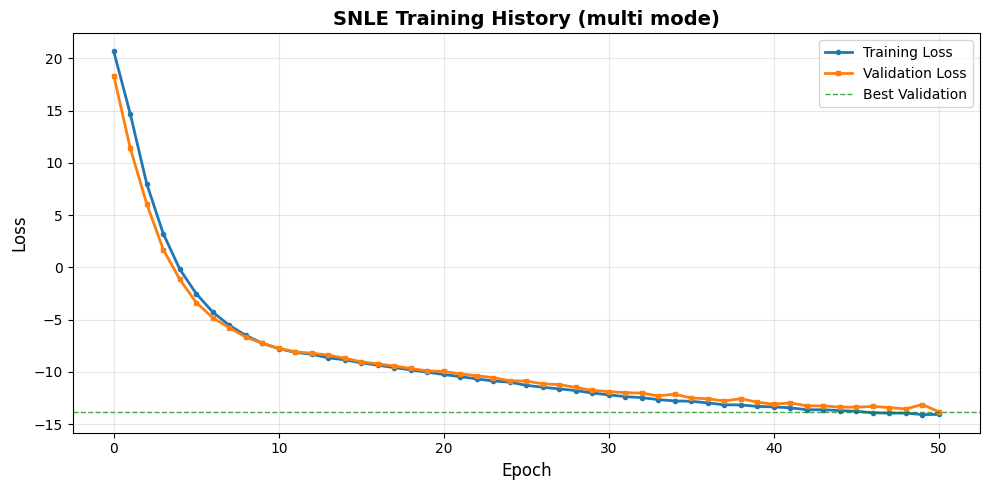


Training Diagnostics:
Epochs trained:        [51]
Final training loss:   -14.0696
Final validation loss: -13.8066
Best validation loss:  -13.8066
Train-val gap:         0.2630

✓ Train-val gap looks reasonable


TypeError: '<' not supported between instances of 'list' and 'int'

In [17]:
torch.manual_seed(0)
    
# Setup
simulator = PatchForagingDDM()
prior = create_prior()

print("="*60)
print("SNLE TRAINING FOR PATCH-LEVEL INFERENCE")
print("="*60)

# Train multi-patch model
likelihood_estimator_multi, inference_multi, x_mean_multi, x_std_multi, history_multi = train_snle(
    simulator, prior, num_simulations=2000, window_sites=100, mode='multi'
)

# Plot training history
plot_training_history(history_multi, mode='multi')

In [11]:
print("\n" + "="*60)
print("TESTING INFERENCE")
print("="*60)

# Test on a simulated patch
true_theta = torch.tensor([0.6, 0.4, 0.3])
print(f"\nTrue parameters: {true_theta}")

# Simulate observed patch
global_time = 0.0
patch_start_time = 0.0


# Test multi-patch inference
param_gen = simulator.constant_params(true_theta)
_, observed_stats_multi = simulator.simulate_trial(param_gen, 100, return_aggregate=True)

print(f"Observed summary stats: {observed_stats_multi}")
print(f"  - Total time: {observed_stats_multi[0]:.2f}")
print(f"  - Num stops: {observed_stats_multi[1]:.0f}")
print(f"  - Num rewards: {observed_stats_multi[2]:.0f}")

# Infer parameters - pass inference object, not likelihood_estimator
posterior_samples_multi = infer_parameters_snle(
    inference_multi, 
    observed_stats_multi, 
    x_mean_multi, 
    x_std_multi,
    num_samples=1000, 
    warmup_steps=200
)

# Analyze results
posterior_mean = posterior_samples_multi.mean(dim=0)
posterior_std = posterior_samples_multi.std(dim=0)

print(f"\nInference results:")
print(f"True parameters:      {true_theta}")
print(f"Posterior mean:       {posterior_mean}")
print(f"Posterior std:        {posterior_std}")
print(f"Absolute error:       {(posterior_mean - true_theta).abs()}")


TESTING INFERENCE

True parameters: tensor([0.6000, 0.4000, 0.3000])
Observed summary stats: tensor([ 3.1003,  0.9419,  3.0588,  1.1532,  1.6471,  1.1776, 56.0000, 34.0000])
  - Total time: 3.10
  - Num stops: 1
  - Num rewards: 3
Running MCMC to infer parameters...


/opt/miniconda3/envs/sbi_ddm_py311/lib/python3.11/site-packages/sbi/inference/trainers/base.py:577: FutureWarning: The following arguments are deprecated and will be removed in a future version: mcmc_parameters. Please use `posterior_parameters` instead. Refer to this guide for details:
https://sbi.readthedocs.io/en/latest/how_to_guide/19_posterior_parameters.html#
  self._raise_deprecation_warning(deprecated_params, **kwargs)


Generating 1 MCMC inits via resample strategy:   0%|          | 0/1 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/6050 [00:00<?, ?it/s]


Inference results:
True parameters:      tensor([0.6000, 0.4000, 0.3000])
Posterior mean:       tensor([0.6620, 0.4590, 0.8676])
Posterior std:        tensor([0.0468, 0.0631, 0.3780])
Absolute error:       tensor([0.0620, 0.0590, 0.5676])


In [ ]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
param_names = ['drift_rate', 'reward_bump', 'failure_bump']

for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.hist(posterior_samples[:, i].numpy(), bins=50, 
            density=True, alpha=0.7, edgecolor='black')
    ax.axvline(true_theta[i].item(), color='red', 
                linestyle='--', linewidth=3, label='True')
    ax.axvline(posterior_mean[i].item(), color='green', 
                linestyle='-', linewidth=2, label='Posterior mean')
    ax.set_xlabel(name)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MNLE: Patch-level Parameter Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sbi.analysis import pairplot

# Generate prior samples for comparison
prior_samples = prior.sample((1000,))

# Create pairplot comparing prior and posterior
fig, ax = pairplot(
    [prior_samples, posterior_samples],
    points=true_theta,  # True parameters as a point
    diag="kde",
    upper="contour", 
    kde_offdiag=dict(bins=50),
    kde_diag=dict(bins=100),
    contour_offdiag=dict(levels=[0.95]),
    points_colors=["red"], 
    points_offdiag=dict(marker="*", markersize=15), 
    labels=[r"drift_rate", r"reward_bump", r"failure_bump"],
    figsize=(10, 10)
)

# Add legend
plt.sca(ax[2, 2])  # Select the bottom-right subplot
plt.legend(
    ["Prior", "Posterior", r"$\theta_{true}$"], 
    frameon=False, 
    fontsize=12,
    loc='upper right'
)

plt.suptitle('SNLE: Prior vs Posterior (Single Patch)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Generate multiple patches from posterior samples to compare distributions
print("\nGenerating patches from posterior samples for comparison...")

num_comparison_patches = 100

# 1. Generate "real" data from true simulator with true parameters
real_patches = []
for _ in range(num_comparison_patches):
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(true_theta, global_time, patch_start_time)
    real_patches.append(stats)
real_data = torch.stack(real_patches)

# 2. Generate "synthetic" data from simulator using posterior-sampled parameters
synthetic_patches = []
for i in range(num_comparison_patches):
    # Sample a parameter from posterior
    theta_sample = posterior_samples[i % len(posterior_samples)]
    
    global_time = 0.0
    patch_start_time = 0.0
    _, _, stats = simulator._simulate_one_patch(theta_sample, global_time, patch_start_time)
    synthetic_patches.append(stats)
synthetic_data = torch.stack(synthetic_patches)

print(f"Real data shape: {real_data.shape}")
print(f"Synthetic data shape: {synthetic_data.shape}")

# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Time in patch distributions
axes[0].hist(synthetic_data[:, 0].numpy(), bins=30, alpha=0.7, label='SNLE', 
             density=True, edgecolor='black')
axes[0].hist(real_data[:, 0].numpy(), bins=30, alpha=0.7, label='Simulator', 
             density=True, edgecolor='black')
axes[0].set_xlabel('Total Time in Patch')
axes[0].set_ylabel('Density')
axes[0].set_title('Patch Duration Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Average rewards comparison
synth_rewards = synthetic_data[:, 2].mean()  # Column 2 is num_rewards
real_rewards = real_data[:, 2].mean()

axes[1].bar(['SNLE', 'Simulator'], [synth_rewards, real_rewards], 
            alpha=0.7, edgecolor='black', capsize=5)
axes[1].set_ylabel('Average Rewards per Patch')
axes[1].set_title('Mean Rewards Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

# Add text labels on bars
for i, (label, value) in enumerate(zip(['SNLE', 'Simulator'], [synth_rewards, real_rewards])):
    axes[1].text(i, value + 0.1, f'{value:.2f}', ha='center', fontsize=10)

# Plot 3: Rewards vs Time scatter
axes[2].scatter(synthetic_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                synthetic_data[:, 0].numpy(), alpha=0.4, label='SNLE', s=20)
axes[2].scatter(real_data[:, 2].numpy() + np.random.normal(0, 0.05, num_comparison_patches), 
                real_data[:, 0].numpy(), alpha=0.4, label='Simulator', s=20)
axes[2].set_xlabel('Number of Rewards (jittered)')
axes[2].set_ylabel('Total Time in Patch')
axes[2].set_title('Rewards vs Time Relationship')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('SNLE vs Simulator: Patch Statistics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nTotal Time in Patch:")
print(f"  SNLE:      {synthetic_data[:, 0].mean():.3f} ± {synthetic_data[:, 0].std():.3f}")
print(f"  Simulator: {real_data[:, 0].mean():.3f} ± {real_data[:, 0].std():.3f}")
print(f"\nNumber of Stops:")
print(f"  SNLE:      {synthetic_data[:, 1].mean():.3f} ± {synthetic_data[:, 1].std():.3f}")
print(f"  Simulator: {real_data[:, 1].mean():.3f} ± {real_data[:, 1].std():.3f}")
print(f"\nNumber of Rewards:")
print(f"  SNLE:      {synthetic_data[:, 2].mean():.3f} ± {synthetic_data[:, 2].std():.3f}")
print(f"  Simulator: {real_data[:, 2].mean():.3f} ± {real_data[:, 2].std():.3f}")
print("="*60)